# Hierarchical Planning

## Imports

In [1]:
import os
import torch
import random
import numpy as np
import pprint

from dataclasses import dataclass
from torch.utils.data import DataLoader

# flow_matching
from flow_matching.solver import ODESolver

# training and evaluation
from src.run import train

from src.pipelines.preprocessing import (
    collate_fn,
    get_dataset_stats,
)
from src.pipelines.eval import (
    WrappedConditionalModel,
    evaluate_open_loop,
    evaluate_policy_mpc,
)
from src.pipelines.sampling import generate_trajectory
from src.models.backbone import ConditionalUNet1D
from src.utils.loggers import WandBLogger

# To avoid meshgrid warning
import warnings

warnings.filterwarnings("ignore", category=UserWarning, module="torch")

if torch.cuda.is_available():
    device = "cuda:0"
    print("Using gpu")
else:
    device = "cpu"
    print("Using cpu.")

torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

Using cpu.


## CCNN Global Planner

In [ ]:
from src.run import load_dataset
@dataclass
class CCNNLunarLanderArgs:
    environment: str = "LunarLander-v3"
    horizon: int = 100
    batch_size: int = 32
    num_epochs: int = 100
    print_every: int = 10
    lr: float = 1e-3
    hidden_dim: int = 128
    kernel_size: int = 5
    step_size: float = 0.05
    solver_method: str = "midpoint"
    inference_batch_size: int = 1
    condition_on: str = "start_obs_goal"
    model_type: str = "ccnn"
    device: str = "cuda:0" if torch.cuda.is_available() else "cpu"
    model_target: str = "obs_only"
args = CCNNLunarLanderArgs()

# Preparing the dataset
config, minari_dataset, env = load_dataset(args, eval_env=True)
action_dim = config.action_dim
obs_dim = config.obs_dim
input_dim = obs_dim * args.horizon
cond_dim = obs_dim * 2
minari_dataset_stats = get_dataset_stats(minari_dataset)
dataloader = DataLoader(minari_dataset, batch_size=args.batch_size, shuffle=True, collate_fn=collate_fn)

SAVE_DIR = "src/checkpoints"
run_name = f"{args.environment}_{args.model_type}_h{args.horizon}_e{args.num_epochs}_k{args.kernel_size}_{args.condition_on}"
MODEL_NAME = run_name + ".pth"
MODEL_SAVE_PATH = os.path.join(SAVE_DIR, MODEL_NAME)
pp = pprint.PrettyPrinter(indent=2)
print("Training configuration:")
pp.pprint(config)
pp.pprint(args)
print("Run name:", run_name)


In [ ]:
logger = WandBLogger(config=args, run_name=run_name)
model, stats, input_dim = train(
    config=config, args=args, env=env, dataset=minari_dataset, logger=logger
)
evaluate_open_loop(env, model, stats, input_dim, args, logger=logger)
logger.finish()

## UNet Global Planner
This one predicts observations only

In [2]:
from src.run import load_dataset


@dataclass
class GlobalLunarLanderArgs:
    environment: str = "LunarLander-v3"
    horizon: int = 100
    batch_size: int = 32
    num_epochs: int = 100
    print_every: int = 10
    lr: float = 1e-3
    hidden_dim: int = 64
    kernel_size: int = 5
    step_size: float = 0.05
    solver_method: str = "midpoint"
    inference_batch_size: int = 1
    condition_on: str = "start_obs_goal"
    model_type: str = "unet"
    device: str = "cuda:0" if torch.cuda.is_available() else "cpu"
    model_target: str = "obs_only"


args = GlobalLunarLanderArgs()

# Preparing the dataset
config, minari_dataset, env = load_dataset(args, eval_env=True)
action_dim = config.action_dim
obs_dim = config.obs_dim
input_dim = obs_dim * args.horizon
cond_dim = obs_dim * 2
minari_dataset_stats = get_dataset_stats(minari_dataset)
dataloader = DataLoader(
    minari_dataset, batch_size=args.batch_size, shuffle=True, collate_fn=collate_fn
)

SAVE_DIR = "src/checkpoints"
run_name = f"{args.environment}_{args.model_type}_h{args.horizon}_e{args.num_epochs}_k{args.kernel_size}_{args.condition_on}_GLOBAL"
MODEL_NAME = run_name + ".pth"
MODEL_SAVE_PATH = os.path.join(SAVE_DIR, MODEL_NAME)
pp = pprint.PrettyPrinter(indent=2)
print("Training configuration:")
pp.pprint(config)
pp.pprint(args)
print("Run name:", run_name)

Training configuration:
LunarLanderConfig(env_name='LunarLander-v3',
                  dataset_name='Box2D/LunarLanderContinuous-v3/expert-v0',
                  obs_dim=8,
                  action_dim=2,
                  category='Box2D')
GlobalLunarLanderArgs(environment='LunarLander-v3',
                      horizon=100,
                      batch_size=32,
                      num_epochs=100,
                      print_every=10,
                      lr=0.001,
                      hidden_dim=64,
                      kernel_size=5,
                      step_size=0.05,
                      solver_method='midpoint',
                      inference_batch_size=1,
                      condition_on='start_obs_goal',
                      model_type='unet',
                      device='cpu',
                      model_target='obs_only')
Run name: LunarLander-v3_unet_h100_e100_k5_start_obs_goal_GLOBAL


In [ ]:
logger = WandBLogger(
    config=args,
    run_name=run_name
)
model, stats, input_dim = train( 
    config=config, args=args, env=env, dataset=minari_dataset, logger=logger
)
evaluate_open_loop(env, model, stats, input_dim, args, logger=logger)
logger.finish()

## UNet Local Planner
This one predicts actions given observations generated by the global planner.

In [3]:
from src.run import load_dataset, build_dataloader
@dataclass
class LocalLunarLanderArgs:
    environment: str = "LunarLander-v3"
    horizon: int = 25
    batch_size: int = 32
    num_epochs: int = 100
    print_every: int = 10
    lr: float = 1e-3
    hidden_dim: int = 64
    kernel_size: int = 5
    step_size: float = 0.05
    solver_method: str = "midpoint"
    inference_batch_size: int = 1
    condition_on: str = "start_obs_goal"
    model_type: str = "unet"
    device: str = "cuda:0" if torch.cuda.is_available() else "cpu"
    model_target: str = "act_only"
args = LocalLunarLanderArgs()

# Preparing the dataset
config, minari_dataset, env = load_dataset(args, eval_env=True)
action_dim = config.action_dim
obs_dim = config.obs_dim
input_dim = action_dim * args.horizon
cond_dim = obs_dim * 2
minari_dataset_stats = get_dataset_stats(minari_dataset)
dataloader = DataLoader(minari_dataset, batch_size=args.batch_size, shuffle=True, collate_fn=collate_fn)

SAVE_DIR = "src/checkpoints"
run_name = f"{args.environment}_{args.model_type}_h{args.horizon}_e{args.num_epochs}_k{args.kernel_size}_{args.condition_on}_LOCAL"
MODEL_NAME = run_name + ".pth"
MODEL_SAVE_PATH = os.path.join(SAVE_DIR, MODEL_NAME)
pp = pprint.PrettyPrinter(indent=2)
print("Training configuration:")
pp.pprint(config)
pp.pprint(args)
print("Run name:", run_name)

Training configuration:
LunarLanderConfig(env_name='LunarLander-v3',
                  dataset_name='Box2D/LunarLanderContinuous-v3/expert-v0',
                  obs_dim=8,
                  action_dim=2,
                  category='Box2D')
LocalLunarLanderArgs(environment='LunarLander-v3',
                     horizon=25,
                     batch_size=32,
                     num_epochs=100,
                     print_every=10,
                     lr=0.001,
                     hidden_dim=64,
                     kernel_size=5,
                     step_size=0.05,
                     solver_method='midpoint',
                     inference_batch_size=1,
                     condition_on='start_obs_goal',
                     model_type='unet',
                     device='cpu',
                     model_target='act_only')
Run name: LunarLander-v3_unet_h25_e100_k5_start_obs_goal_LOCAL


In [ ]:
logger = WandBLogger(
    config=args,
    run_name=run_name
)
model, stats, input_dim = train( 
    config=config, args=args, dataset=minari_dataset, logger=logger
)
logger.finish()

## MPC Evaluation
1. call the global planner to get a sequence of observations
2. use the output of the global planner as conditioning signals for the local planner

In [4]:
args = LocalLunarLanderArgs()
pp.pprint(args)
MODEL_SAVE_PATH = "src/checkpoints/LunarLander-v3_unet_h25_e100_k5_start_obs_goal_LOCAL.pth"
print(f"Loading model from {MODEL_SAVE_PATH}...")
state_dict = torch.load(MODEL_SAVE_PATH, map_location=device)
vf = ConditionalUNet1D(
    horizon=args.horizon,
    input_dim=input_dim,
    hidden_dim=args.hidden_dim,
    cond_dim=cond_dim,
).to(device)
vf.load_state_dict(state_dict)

wrapped_vf = WrappedConditionalModel(vf)
step_size = 0.05
T = torch.linspace(0, 1, 10)  # sample times
T = T.to(device=device)
solver = ODESolver(velocity_model=wrapped_vf)  # create an ODESolver class

LocalLunarLanderArgs(environment='LunarLander-v3',
                     horizon=25,
                     batch_size=32,
                     num_epochs=100,
                     print_every=10,
                     lr=0.001,
                     hidden_dim=64,
                     kernel_size=5,
                     step_size=0.05,
                     solver_method='midpoint',
                     inference_batch_size=1,
                     condition_on='start_obs_goal',
                     model_type='unet',
                     device='cpu',
                     model_target='act_only')
Loading model from src/checkpoints/LunarLander-v3_unet_h25_e100_k5_start_obs_goal_LOCAL.pth...


### Testing local planner
We first test the local planner on its own...


--- Starting MPC Evaluation (Condition Type: start_obs_goal) and Replan Frequency: 1 ---
Episode 1/10 finished. Total Reward: 125.90
  Average '<lambda>' time this episode: 0.0536s
Episode 2/10 finished. Total Reward: 170.62
  Average '<lambda>' time this episode: 0.0502s
Episode 3/10 finished. Total Reward: 136.80
  Average '<lambda>' time this episode: 0.0516s
Episode 4/10 finished. Total Reward: 117.29
  Average '<lambda>' time this episode: 0.0512s
Episode 5/10 finished. Total Reward: 118.62
  Average '<lambda>' time this episode: 0.0506s
Episode 6/10 finished. Total Reward: 109.63
  Average '<lambda>' time this episode: 0.0501s
Episode 7/10 finished. Total Reward: 136.79
  Average '<lambda>' time this episode: 0.0495s
Episode 8/10 finished. Total Reward: 115.25
  Average '<lambda>' time this episode: 0.0498s
Episode 9/10 finished. Total Reward: 163.93
  Average '<lambda>' time this episode: 0.0498s
Episode 10/10 finished. Total Reward: 115.87
  Average '<lambda>' time this episod

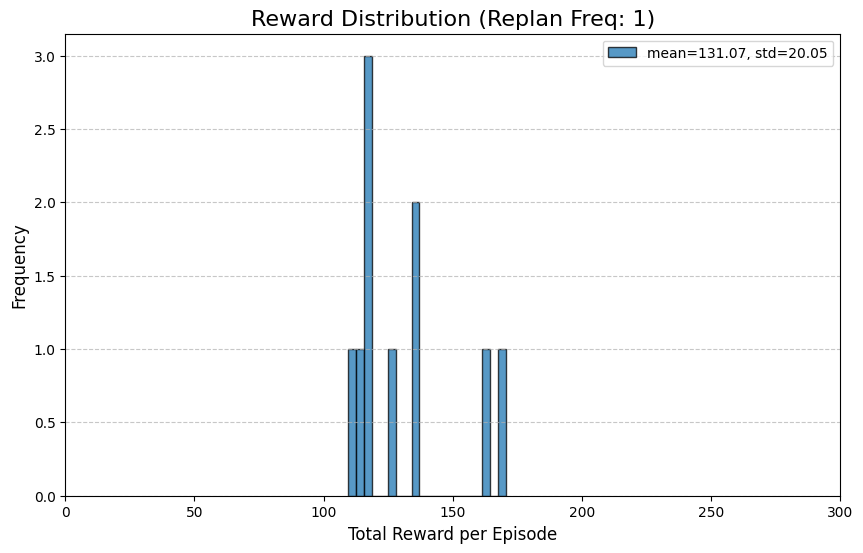

In [5]:
final_goal_state = torch.tensor([0, 0, 0, 0, 0, 0, 1, 1], dtype=torch.float32)

local_planner = lambda cond_dict: generate_trajectory(
    stats=minari_dataset_stats,
    solver=solver,
    T=T,
    input_dim=input_dim,
    horizon=args.horizon,
    condition=cond_dict,
    batch_size=args.inference_batch_size,
    model_target=args.model_target,
)
model_rewards = evaluate_policy_mpc(
    env=env,
    planner_fn=local_planner,
    num_episodes=10,
    replan_freq=1,
    render=False,
    max_episode_length=300,
    condition_type="start_obs_goal",
    goal_obs= final_goal_state,
)
env.close()

In [ ]:
# Global model (obs | start_obs, goal_obs)
GLOBAL_MODEL_PATH = (
    "src/checkpoints/LunarLander-v3_unet_h100_e100_k5_start_obs_goal.pth"
)
global_args = GlobalLunarLanderArgs(model_target="obs_only")
pp.pprint(global_args)
obs_input_dim = config.obs_dim * global_args.horizon
gmodel = ConditionalUNet1D(
    horizon=global_args.horizon,
    input_dim=obs_input_dim,
    hidden_dim=global_args.hidden_dim,
    cond_dim=config.obs_dim * 2,
).to(device)
gmodel.load_state_dict(torch.load(GLOBAL_MODEL_PATH, map_location=device))
gsolver = ODESolver(WrappedConditionalModel(gmodel))
gT = torch.linspace(0, 1, 10).to(device)


# Local model (act | start_obs, end_obs)
LOCAL_MODEL_PATH = (
    "src/checkpoints/LunarLander-v3_unet_h25_e100_k5_start_obs_goal_LOCAL.pth"
)
local_args = LocalLunarLanderArgs(model_target="act_only")
pp.pprint(local_args)
act_input_dim = config.action_dim * local_args.horizon
lmodel = ConditionalUNet1D(
    horizon=local_args.horizon,
    input_dim=act_input_dim,
    hidden_dim=local_args.hidden_dim,
    cond_dim=config.obs_dim * 2,
).to(device)
lmodel.load_state_dict(torch.load(LOCAL_MODEL_PATH, map_location=device))
lsolver = ODESolver(WrappedConditionalModel(lmodel))
lT = torch.linspace(0, 1, 10).to(device)

# Wrappers that sample from each planner
global_planner = lambda cond: generate_trajectory(
    stats=minari_dataset_stats,
    solver=gsolver,
    T=gT,
    input_dim=obs_input_dim,
    horizon=global_args.horizon,
    condition=cond,
    batch_size=1,
    model_target="obs_only",
)
local_planner = lambda cond: generate_trajectory(
    stats=minari_dataset_stats,
    solver=lsolver,
    T=lT,
    input_dim=act_input_dim,
    horizon=local_args.horizon,
    condition=cond,
    batch_size=1,
    model_target="act_only",
)

GlobalLunarLanderArgs(environment='LunarLander-v3',
                      horizon=100,
                      batch_size=32,
                      num_epochs=100,
                      print_every=10,
                      lr=0.001,
                      hidden_dim=64,
                      kernel_size=5,
                      step_size=0.05,
                      solver_method='midpoint',
                      inference_batch_size=1,
                      condition_on='start_obs_goal',
                      model_type='unet',
                      device='cpu',
                      model_target='obs_only')
LocalLunarLanderArgs(environment='LunarLander-v3',
                     horizon=25,
                     batch_size=32,
                     num_epochs=100,
                     print_every=10,
                     lr=0.001,
                     hidden_dim=64,
                     kernel_size=5,
                     step_size=0.05,
                     solver_method='midpoint',
    

In [ ]:
from src.pipelines.lunarlander.planners import StatefulHierarchicalPlanner

final_goal_state = torch.tensor([0, 0, 0, 0, 0, 0, 1, 1], dtype=torch.float32)
hierarchical_planner = StatefulHierarchicalPlanner(
    global_planner, local_planner, global_replan_freq=20
)
rewards = evaluate_policy_mpc(
    env=env,
    planner_fn=hierarchical_planner,
    num_episodes=10,
    condition_type="start_obs_goal",
    goal_obs=final_goal_state,
    max_episode_length=300,
    replan_freq=1,
    render=False,
)
env.close()


--- Starting MPC Evaluation (Condition Type: start_obs_goal) and Replan Frequency: 1 ---
Episode 1/10 finished. Total Reward: 140.33
  Average inference time this episode: 0.0692s
Episode 2/10 finished. Total Reward: 121.80
  Average inference time this episode: 0.0683s
Episode 3/10 finished. Total Reward: 154.10
  Average inference time this episode: 0.0689s
